# Q-learning 뉴럴넷 구현: 3x4 그리드 월드 예제

### GridWorld 시각화를 위한 설정

In [1]:
import os
import urllib.request

if not os.path.exists("gridworld_render.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/common/gridworld_render.py"
    filename = "gridworld_render.py"
    urllib.request.urlretrieve(url, filename)

if not os.path.exists("gridworld.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/common/gridworld.py"
    filename = "gridworld.py"
    urllib.request.urlretrieve(url, filename)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from gridworld import GridWorld
import warnings

# 경고 메시지 출력 표기 생략
warnings.filterwarnings('ignore')

### state 를 받아 one-hot encoding

In [ ]:
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)

    # state 에 해당하는 원소만 1.0으로 설정
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0

    # 배치 처리를 위해 새로운 축 추가
    return torch.from_numpy(vec[np.newaxis, :])  # Return as torch tensor

In [4]:
class QNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(12, 100)   # input:12, 중간층의 크기:100
        self.l2 = nn.Linear(100, 4)    # 행동의 크기(가능한 행동의 개수, output:4)

    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = self.l2(x)
        return x

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        self.qnet = QNet()  # 신경망 초기화
        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)   # 옵티마이저 생성
        self.loss_fn = nn.MSELoss() # 손실 함수 정의 (MSE)

    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon: 
            return np.random.choice(self.action_size) # 탐험: 랜덤 행동 선택
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec.float())   # 현재 상태 벡터에 대한 Q값 계산
                return qs.argmax().item()           # 최대 Q값을 갖는 행동 선택

    def update(self, state, action, reward, next_state, done):
        state = state.float()           # 상태 벡터를 torch tensor로 변환
        next_state = next_state.float() # 다음 상태 벡터를 torch tensor로 변환
        q_values = self.qnet(state)     # 현재 상태의 Q값
        q_value = q_values[0, action]   # 현재 상태에서 선택한 행동의 Q값

        # Q-learning 업데이트
        with torch.no_grad():   
            if done:
                # 에피소드가 끝났을 때, 다음 상태가 없으므로 보상만 사용
                target = torch.tensor([reward], dtype=torch.float32) 
            else:
                next_q_values = self.qnet(next_state)   # 다음 상태의 Q값
                next_q = next_q_values.max(1)[0]        # 다음 상태에서 최대 Q값 선택
                target = reward + self.gamma * next_q   # 현재 상태에서 선택한 행동의 Q값 업데이트(타겟 Q값 계산)

        loss = self.loss_fn(q_value, target)    # 목표(target)와 q의 오차 계산
        self.optimizer.zero_grad()              # 기울기 초기화
        loss.backward()                         # 역전파로 기울기 계산
        self.optimizer.step()                   # 가중치 업데이트

        return loss.item()

In [6]:
env = GridWorld()
agent = QLearningAgent()

episodes = 1000  # 에피소드 수
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state

    average_loss = total_loss / cnt     # 에피소드당 평균 손실 계산
    loss_history.append(average_loss)

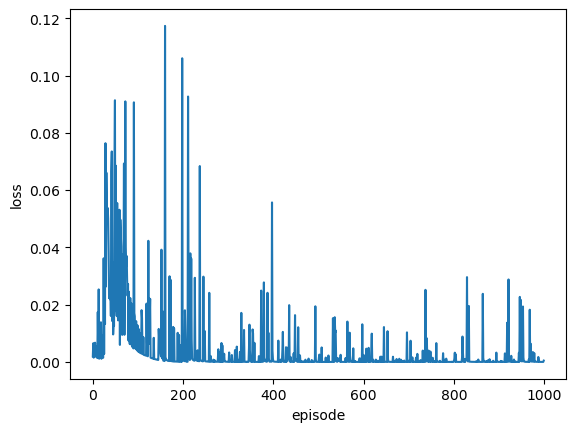

In [7]:
# 에피소드별 손실 추이 그래프
plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

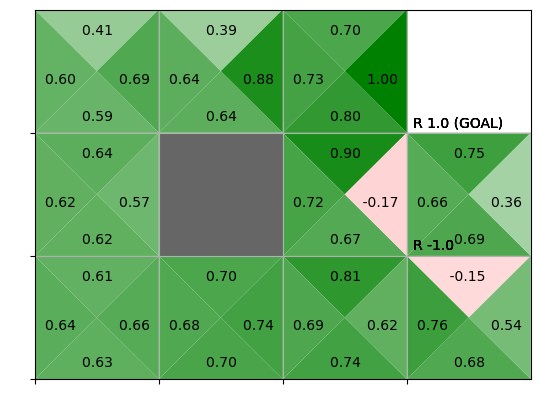

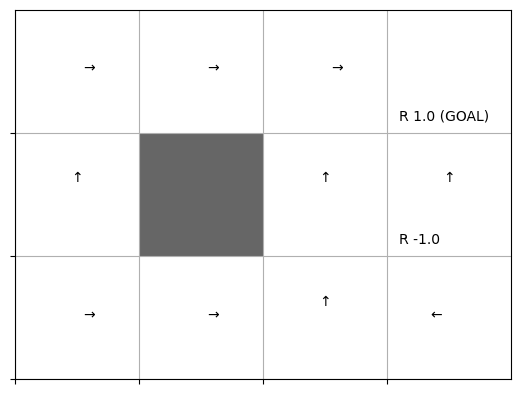

In [ ]:
# 신경망을 이용한 Q 러닝으로 얻은 Q 함수와 정책
Q = {}
for state in env.states():
    for action in env.action_space:
        with torch.no_grad():
            q = agent.qnet(one_hot(state).float())[0, action] # Q값 계산
            Q[state, action] = float(q.item())
env.render_q(Q)